In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("✅ All imports working")

✅ All imports working


In [2]:
df = pd.read_csv("machine_measurements.csv")
print("✅ Loaded!")
print(f"Rows: {len(df):,}")

C:\Users\linds\AppData\Local\Temp\ipykernel_26120\1718775674.py:1: DtypeWarning: Columns (0: report_12, 1: report_13, 2: report_14, 3: report_15, 4: report_16, 5: report_17) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("machine_measurements.csv")


✅ Loaded!
Rows: 800,035


In [3]:
print(list(df.columns))

['subject_id', 'study_id', 'cart_id', 'ecg_time', 'report_0', 'report_1', 'report_2', 'report_3', 'report_4', 'report_5', 'report_6', 'report_7', 'report_8', 'report_9', 'report_10', 'report_11', 'report_12', 'report_13', 'report_14', 'report_15', 'report_16', 'report_17', 'bandwidth', 'filtering', 'rr_interval', 'p_onset', 'p_end', 'qrs_onset', 'qrs_end', 't_end', 'p_axis', 'qrs_axis', 't_axis']


In [4]:
# Look at a few rows to see what the report columns contain
print(df[['report_0', 'report_1', 'report_2', 'report_3']].head(10))

                    report_0  \
0               Sinus rhythm   
1               Sinus rhythm   
2          Sinus tachycardia   
3               Sinus rhythm   
4               Sinus rhythm   
5               Sinus rhythm   
6               Sinus rhythm   
7               Sinus rhythm   
8  Sinus rhythm with PAC(s).   
9               Sinus rhythm   

                                            report_1  \
0                  Possible right atrial abnormality   
1                  Possible right atrial abnormality   
2                                                NaN   
3                                                NaN   
4                                                NaN   
5                                                NaN   
6                                                NaN   
7                 rSr'(V1) - probable normal variant   
8                                                NaN   
9  Extensive T wave changes may be due to myocard...   

                              

In [5]:
print(df['report_0'].value_counts().head(20))

report_0
Sinus rhythm                                                                      317278
Sinus rhythm.                                                                      59739
Sinus bradycardia                                                                  58924
Sinus tachycardia                                                                  40528
Atrial fibrillation                                                                31961
Sinus tachycardia.                                                                 13252
Sinus rhythm with borderline 1st degree A-V block                                  11983
Sinus bradycardia.                                                                 11333
Sinus rhythm with 1st degree A-V block                                             11194
Sinus arrhythmia                                                                   11092
Atrial fibrillation with rapid ventricular response                                 8923
*** CONSIDER

In [6]:
# Isolate AFib cases
afib = df[df['report_0'] == 'Atrial fibrillation']
normal = df[df['report_0'] == 'Sinus rhythm']

print(f"AFib cases:   {len(afib):,}")
print(f"Sinus rhythm: {len(normal):,}")
print(f"\nAFib prevalence: {len(afib)/len(df)*100:.1f}%")

AFib cases:   31,961
Sinus rhythm: 317,278

AFib prevalence: 4.0%


In [7]:
# Compare RR intervals between AFib and normal
print("RR Interval stats:")
print(f"\nAFib:")
print(afib['rr_interval'].describe())
print(f"\nSinus rhythm:")
print(normal['rr_interval'].describe())

RR Interval stats:

AFib:
count    31961.000000
mean       762.607052
std        387.917114
min        335.000000
25%        666.000000
50%        750.000000
75%        857.000000
max      65535.000000
Name: rr_interval, dtype: float64

Sinus rhythm:
count    317278.000000
mean        808.990239
std         113.109988
min         352.000000
25%         714.000000
50%         810.000000
75%         895.000000
max        1500.000000
Name: rr_interval, dtype: float64


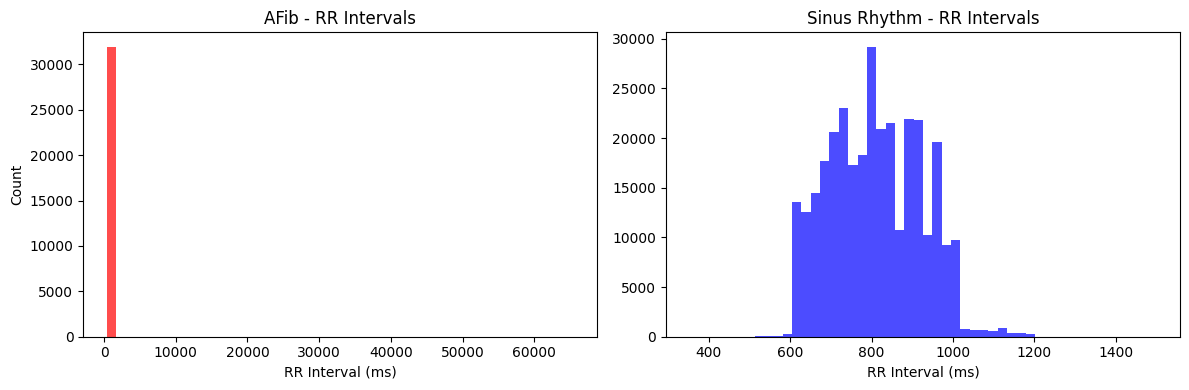

In [8]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(afib['rr_interval'].dropna(), bins=50, color='red', alpha=0.7)
plt.title('AFib - RR Intervals')
plt.xlabel('RR Interval (ms)')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
plt.hist(normal['rr_interval'].dropna(), bins=50, color='blue', alpha=0.7)
plt.title('Sinus Rhythm - RR Intervals')
plt.xlabel('RR Interval (ms)')

plt.tight_layout()
plt.show()

In [9]:
# Check what's reasonable - normal RR interval is 300-2000ms
print("AFib RR interval range:")
print(f"  Min: {afib['rr_interval'].min()}")
print(f"  Max: {afib['rr_interval'].max()}")

# How many are outside physiological range?
bad = afib[(afib['rr_interval'] < 300) | (afib['rr_interval'] > 2000)]
print(f"\nOutliers outside 300-2000ms: {len(bad):,} ({len(bad)/len(afib)*100:.1f}%)")

AFib RR interval range:
  Min: 335
  Max: 65535

Outliers outside 300-2000ms: 3 (0.0%)


AFib after cleaning: 31,958 (removed 3)
Normal after cleaning: 317,278


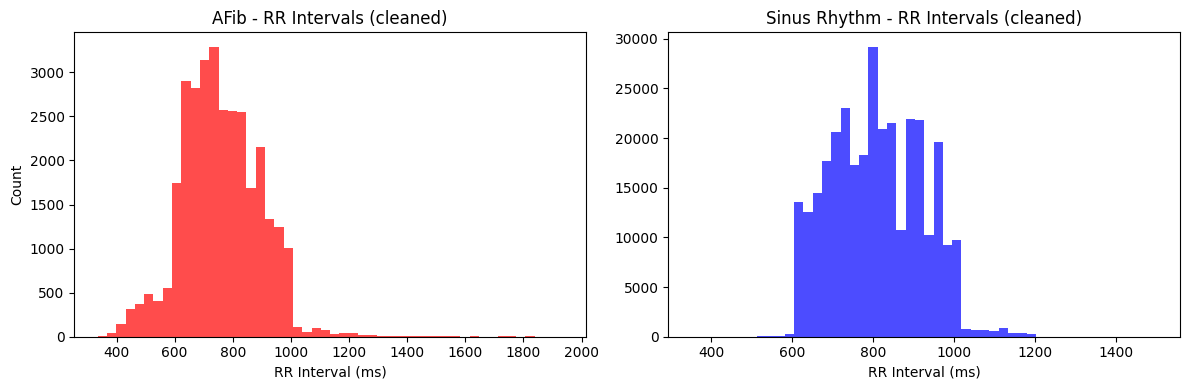

In [10]:
# Filter to physiological range
afib_clean = afib[(afib['rr_interval'] >= 300) & (afib['rr_interval'] <= 2000)]
normal_clean = normal[(normal['rr_interval'] >= 300) & (normal['rr_interval'] <= 2000)]

print(f"AFib after cleaning: {len(afib_clean):,} (removed {len(afib)-len(afib_clean)})")
print(f"Normal after cleaning: {len(normal_clean):,}")

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(afib_clean['rr_interval'].dropna(), bins=50, color='red', alpha=0.7)
plt.title('AFib - RR Intervals (cleaned)')
plt.xlabel('RR Interval (ms)')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
plt.hist(normal_clean['rr_interval'].dropna(), bins=50, color='blue', alpha=0.7)
plt.title('Sinus Rhythm - RR Intervals (cleaned)')
plt.xlabel('RR Interval (ms)')

plt.tight_layout()
plt.show()

In [11]:
# Compare all available features between AFib and normal
features = ['rr_interval', 'p_onset', 'p_end', 'qrs_onset', 'qrs_end', 't_end', 'p_axis', 'qrs_axis', 't_axis']

for f in features:
    afib_mean = afib_clean[f].mean()
    normal_mean = normal_clean[f].mean()
    print(f"{f:15} AFib: {afib_mean:8.1f}  Normal: {normal_mean:8.1f}")

rr_interval     AFib:    760.5  Normal:    809.0
p_onset         AFib:  23502.8  Normal:    103.5
p_end           AFib:  29999.0  Normal:   6463.9
qrs_onset       AFib:    266.6  Normal:    261.5
qrs_end         AFib:    372.4  Normal:    356.5
t_end           AFib:    666.4  Normal:    655.3
p_axis          AFib:  28832.4  Normal:     51.8
qrs_axis        AFib:     59.0  Normal:     24.1
t_axis          AFib:    287.9  Normal:     95.9


In [12]:
# P wave absence as AFib signal
print("P-axis distribution:")
print(f"AFib p_axis > 1000:   {(afib_clean['p_axis'] > 1000).sum():,} ({(afib_clean['p_axis'] > 1000).mean()*100:.1f}%)")
print(f"Normal p_axis > 1000: {(normal_clean['p_axis'] > 1000).sum():,} ({(normal_clean['p_axis'] > 1000).mean()*100:.1f}%)")

P-axis distribution:
AFib p_axis > 1000:   30,222 (94.6%)
Normal p_axis > 1000: 43 (0.0%)


In [13]:
# What else has p_axis > 1000?
suspicious = df[df['p_axis'] > 1000]
print("report_0 diagnoses with p_axis > 1000:")
print(suspicious['report_0'].value_counts().head(20))

report_0 diagnoses with p_axis > 1000:
report_0
Atrial fibrillation                                        30225
Atrial fibrillation with rapid ventricular response         8923
Atrial fibrillation.                                        8493
Ventricular pacing                                          6545
Atrial fibrillation with rapid ventricular response.        5837
Atrial fibrillation with slow ventricular response          4475
Atrial pacing                                               3667
Possible atrial flutter                                     2291
Demand pacing                                               2199
--- Warning: Data quality may affect interpretation ---     2159
*** CONSIDER ACUTE ST ELEVATION MI ***                      2072
A-V sequential pacemaker                                    2006
Ventricular pacing.                                         1900
Accelerated idioventricular rhythm                          1739
Regular supraventricular rhythm           

In [14]:
# Build a more complete picture
# Label everything in our dataset

df_clean = df[(df['rr_interval'] >= 300) & (df['rr_interval'] <= 2000)].copy()

# Create AFib label (all AFib variants)
df_clean['is_afib'] = df_clean['report_0'].str.contains(
    'Atrial fibrillation', na=False
).astype(int)

# Our detector: p_axis > 1000
df_clean['predicted_afib'] = (df_clean['p_axis'] > 1000).astype(int)

# Calculate performance
TP = ((df_clean['is_afib'] == 1) & (df_clean['predicted_afib'] == 1)).sum()
FN = ((df_clean['is_afib'] == 1) & (df_clean['predicted_afib'] == 0)).sum()
TN = ((df_clean['is_afib'] == 0) & (df_clean['predicted_afib'] == 0)).sum()
FP = ((df_clean['is_afib'] == 0) & (df_clean['predicted_afib'] == 1)).sum()

sensitivity = TP / (TP + FN) * 100
specificity = TN / (TN + FP) * 100

print(f"True Positives (caught AFib):    {TP:,}")
print(f"False Negatives (missed AFib):   {FN:,}")
print(f"True Negatives (correct normal): {TN:,}")
print(f"False Positives (false alarms):  {FP:,}")
print(f"\nSensitivity: {sensitivity:.1f}%")
print(f"Specificity: {specificity:.1f}%")
print(f"\nFDA benchmark: 96-99%")

# What are we falsely flagging?
print(f"\nWhat are our false positives?")
fp_cases = df_clean[(df_clean['is_afib'] == 0) & (df_clean['predicted_afib'] == 1)]
print(fp_cases['report_0'].value_counts().head(10))

True Positives (caught AFib):    72,552
False Negatives (missed AFib):   1,871
True Negatives (correct normal): 667,144
False Positives (false alarms):  56,652

Sensitivity: 97.5%
Specificity: 92.2%

FDA benchmark: 96-99%

What are our false positives?
report_0
Ventricular pacing                        6540
Atrial pacing                             3667
Possible atrial flutter                   2291
Demand pacing                             2197
*** CONSIDER ACUTE ST ELEVATION MI ***    2063
A-V sequential pacemaker                  2004
Ventricular pacing.                       1898
Accelerated idioventricular rhythm        1739
Regular supraventricular rhythm           1717
Undetermined rhythm                       1323
Name: count, dtype: int64


In [15]:
print(f"Total ECG readings: {len(df_clean):,}")
print(f"Unique patients:    {df_clean['subject_id'].nunique():,}")
print(f"Avg readings per patient: {len(df_clean)/df_clean['subject_id'].nunique():.1f}")

Total ECG readings: 798,219
Unique patients:    161,327
Avg readings per patient: 4.9


In [16]:
# Patient-level analysis
# For each patient, take their FIRST reading only
df_first = df_clean.sort_values('ecg_time').groupby('subject_id').first().reset_index()

print(f"Patient-level dataset: {len(df_first):,} unique patients")
print(f"AFib patients: {df_first['is_afib'].sum():,} ({df_first['is_afib'].mean()*100:.1f}%)")

# Recalculate performance at patient level
TP = ((df_first['is_afib'] == 1) & (df_first['predicted_afib'] == 1)).sum()
FN = ((df_first['is_afib'] == 1) & (df_first['predicted_afib'] == 0)).sum()
TN = ((df_first['is_afib'] == 0) & (df_first['predicted_afib'] == 0)).sum()
FP = ((df_first['is_afib'] == 0) & (df_first['predicted_afib'] == 1)).sum()

sensitivity = TP / (TP + FN) * 100
specificity = TN / (TN + FP) * 100

print(f"\nPatient-level performance:")
print(f"Sensitivity: {sensitivity:.1f}%")
print(f"Specificity: {specificity:.1f}%")
print(f"\nReading-level was higher? That's the repeat patient inflation.")

Patient-level dataset: 161,327 unique patients
AFib patients: 8,227 (5.1%)

Patient-level performance:
Sensitivity: 95.7%
Specificity: 96.6%

Reading-level was higher? That's the repeat patient inflation.


In [17]:
# Multi-feature confidence scoring
df_first = df_first.copy()

# Each feature votes
df_first['score'] = (
    ((df_first['p_axis'] > 1000).astype(int) * 2) +
    ((df_first['p_onset'] > 500).astype(int) * 1) +
    ((df_first['p_end'] > 1000).astype(int) * 1) +
    ((df_first['t_axis'] > 200).astype(int) * 1) +
    ((df_first['rr_interval'] > 900).astype(int) * 1)
)

# Three buckets
df_first['routing'] = pd.cut(
    df_first['score'],
    bins=[-1, 1, 3, 6],
    labels=['Confident Normal', 'Human Review', 'Confident AFib']
)

print(df_first['routing'].value_counts())
print(f"\nOf those routed to Human Review:")
print(df_first[df_first['routing'] == 'Human Review']['is_afib'].value_counts())

routing
Confident Normal    141299
Confident AFib       12280
Human Review          7748
Name: count, dtype: int64

Of those routed to Human Review:
is_afib
0    6985
1     763
Name: count, dtype: int64


In [18]:
# Performance on just the automatic routing (excluding human review)
auto = df_first[df_first['routing'] != 'Human Review']

TP = ((auto['is_afib'] == 1) & (auto['routing'] == 'Confident AFib')).sum()
FN = ((auto['is_afib'] == 1) & (auto['routing'] == 'Confident Normal')).sum()
TN = ((auto['is_afib'] == 0) & (auto['routing'] == 'Confident Normal')).sum()
FP = ((auto['is_afib'] == 0) & (auto['routing'] == 'Confident AFib')).sum()

sensitivity = TP / (TP + FN) * 100
specificity = TN / (TN + FP) * 100

print(f"Automatic routing performance (excluding human review):")
print(f"Sensitivity: {sensitivity:.1f}%")
print(f"Specificity: {specificity:.1f}%")
print(f"\nCases handled automatically: {len(auto):,} ({len(auto)/len(df_first)*100:.1f}%)")
print(f"Cases escalated to human:   {7748:,} ({7748/len(df_first)*100:.1f}%)")
print(f"\nFDA benchmark: 96-99%")

Automatic routing performance (excluding human review):
Sensitivity: 96.2%
Specificity: 96.5%

Cases handled automatically: 153,579 (95.2%)
Cases escalated to human:   7,748 (4.8%)

FDA benchmark: 96-99%


In [19]:
# GOVERNANCE LAYER - Authority Matrix
authority_matrix = {
    'Confident Normal': {
        'action': 'Auto-route to downstream system',
        'authority': 'Algorithm',
        'review_required': False,
        'escalation_path': None,
        'response_time': 'Immediate'
    },
    'Confident AFib': {
        'action': 'Auto-alert cardiology pipeline',
        'authority': 'Algorithm',
        'review_required': False,
        'escalation_path': 'Cardiologist if patient symptomatic',
        'response_time': 'Immediate'
    },
    'Human Review': {
        'action': 'Route to clinical review queue',
        'authority': 'Attending physician',
        'review_required': True,
        'escalation_path': 'Cardiologist if confirmed AFib',
        'response_time': '< 4 hours'
    }
}

for tier, rules in authority_matrix.items():
    print(f"\n{'='*40}")
    print(f"TIER: {tier}")
    for k, v in rules.items():
        print(f"  {k}: {v}")


TIER: Confident Normal
  action: Auto-route to downstream system
  authority: Algorithm
  review_required: False
  escalation_path: None
  response_time: Immediate

TIER: Confident AFib
  action: Auto-alert cardiology pipeline
  authority: Algorithm
  review_required: False
  escalation_path: Cardiologist if patient symptomatic
  response_time: Immediate

TIER: Human Review
  action: Route to clinical review queue
  authority: Attending physician
  review_required: True
  escalation_path: Cardiologist if confirmed AFib
  response_time: < 4 hours


In [20]:
# What's actually in our human review bucket?
human_review = df_first[df_first['routing'] == 'Human Review']

print("Diagnoses in Human Review bucket:")
print(human_review['report_0'].value_counts().head(30))

Diagnoses in Human Review bucket:
report_0
Sinus rhythm                                                                      4101
Sinus bradycardia                                                                 1760
Atrial fibrillation                                                                737
Age not entered, assumed to be  50 years old for purpose of ECG interpretation     427
Sinus tachycardia                                                                  155
Sinus arrhythmia                                                                    93
Sinus or ectopic atrial rhythm                                                      54
Slow sinus arrhythmia                                                               38
Atrial flutter                                                                      27
Atrial fibrillation with rapid V-rate                                               26
Sinus or ectopic atrial bradycardia                                                 24


In [21]:
# Define urgency mapping
urgent = [
    'AV block, complete (third degree)',
    'Junctional tachycardia',
    'Supraventricular tachycardia'
]

soon = [
    'Atrial fibrillation',
    'Atrial fibrillation with rapid V-rate',
    'Atrial flutter',
    'Afib/flut and V-paced complexes',
    'Atrial fibrillation with rapid ventricular response',
    'Bradycardia with irregular rate'
]

def assign_urgency(row):
    if row['routing'] != 'Human Review':
        return row['routing']  # keep automatic routing as-is
    diagnosis = str(row['report_0'])
    if any(u in diagnosis for u in urgent):
        return 'URGENT < 15min'
    elif any(s in diagnosis for s in soon):
        return 'SOON < 1hr'
    else:
        return 'ROUTINE < 4hr'

df_first['final_routing'] = df_first.apply(assign_urgency, axis=1)

print(df_first['final_routing'].value_counts())

final_routing
Confident Normal    141299
Confident AFib       12280
ROUTINE < 4hr         6874
SOON < 1hr             836
URGENT < 15min          38
Name: count, dtype: int64


In [22]:
# Where did STEMI cases end up?
stemi = df_first[df_first['report_0'].str.contains('STEMI|ST ELEVATION|ST elevation', na=False, case=False)]
print(f"STEMI cases in patient-level dataset: {len(stemi)}")
print(stemi['final_routing'].value_counts())
print("\nSTEMI report_0 values:")
print(stemi['report_0'].value_counts())

STEMI cases in patient-level dataset: 1149
final_routing
Confident Normal    951
Confident AFib      198
Name: count, dtype: int64

STEMI report_0 values:
report_0
*** CONSIDER ACUTE ST ELEVATION MI ***    1149
Name: count, dtype: int64


In [23]:
# Find all unique report_0 values that might be critical
# Cast a wide net first
critical_search = ['ST', 'ventric', 'tampon', 'flutter', 
                   'block', 'torsade', 'fibril', 'ACUTE', 'MI']

for term in critical_search:
    matches = df_first[df_first['report_0'].str.contains(
        term, na=False, case=False)]['report_0'].value_counts()
    if len(matches) > 0:
        print(f"\n--- '{term}' ---")
        print(matches.head(5))


--- 'ST' ---
report_0
Sinus rhythm with borderline 1st degree A-V block         2062
Sinus rhythm with 1st degree A-V block                    1476
*** CONSIDER ACUTE ST ELEVATION MI ***                    1149
Sinus bradycardia with borderline 1st degree A-V block     781
Sinus bradycardia with 1st degree A-V block                717
Name: count, dtype: int64

--- 'ventric' ---
report_0
Atrial fibrillation with rapid ventricular response     1092
Atrial fibrillation with slow ventricular response       536
Ventricular pacing                                       481
Atrial fibrillation with rapid ventricular response.     442
Regular supraventricular rhythm                          244
Name: count, dtype: int64

--- 'flutter' ---
report_0
Possible atrial flutter                                              215
Atrial flutter                                                       138
Possible atrial flutter with rapid ventricular response              126
Atrial flutter with rapid vent

In [24]:
# CRITICAL safety pre-filter
# Keywords chosen based on actual data strings - precise, not broad

critical_keywords = [
    '*** CONSIDER ACUTE ST ELEVATION MI ***',     # exact match - STEMI
    'rapid ventricular response',                  # AFib/flutter RVR
    'ventricular fibrillation',                    # VFib
    'ventricular tachycardia',                     # VTach  
    'torsade',                                     # Torsades
    'third degree',                                # Complete heart block
    'complete heart block',                        # Complete heart block alt string
    'AV block, complete',                          # Another variant
]

def safety_prefilter(row):
    diagnosis = str(row['report_0']).lower()
    if any(k.lower() in diagnosis for k in critical_keywords):
        return 'CRITICAL - IMMEDIATE'
    return row['final_routing']

df_first['final_routing'] = df_first.apply(safety_prefilter, axis=1)

print(df_first['final_routing'].value_counts())
print(f"\nCritical cases rescued from auto-routing:")
critical = df_first[df_first['final_routing'] == 'CRITICAL - IMMEDIATE']
print(critical['report_0'].value_counts().head(10))

final_routing
Confident Normal        140313
Confident AFib            9538
ROUTINE < 4hr             6874
CRITICAL - IMMEDIATE      3755
SOON < 1hr                 836
URGENT < 15min              11
Name: count, dtype: int64

Critical cases rescued from auto-routing:
report_0
*** CONSIDER ACUTE ST ELEVATION MI ***                                                                1149
Atrial fibrillation with rapid ventricular response                                                   1092
Atrial fibrillation with rapid ventricular response.                                                   442
Possible atrial flutter with rapid ventricular response                                                126
Atrial flutter with rapid ventricular response with 2:1 A-V block                                       91
Probable supraventricular tachycardia                                                                   75
Atrial fibrillation with rapid ventricular response with PVC(s)                 

In [27]:
df_monitor = df_first.sort_values('ecg_time').copy()
# ============================================================
# STOP MECHANISMS WITH FAILOVER
# Adapted from clinical lab QC - Westgard rules for AI
# ============================================================

import numpy as np
from datetime import datetime

# --- GOVERNANCE THRESHOLDS ---
# Based on FDA-cleared device benchmarks
THRESHOLDS = {
    'min_sensitivity':     0.95,   # below this → failover
    'max_false_positive':  0.05,   # above this → alert
    'critical_miss_rate':  0.0,    # any critical miss → immediate stop
    'rolling_window':      500,    # cases per evaluation window
    'min_window_size':     100     # minimum cases before evaluating
}

# --- SIMULATED BACKUP MODEL ---
# In real deployment this would be a different algorithm
# For demo: backup is more conservative (flags more for human review)
def backup_model(row):
    # Lower confidence threshold = more human review, fewer auto-routes
    if row['p_axis'] > 500:  # more sensitive threshold
        return 'Human Review - BACKUP MODEL'
    return 'Confident Normal - BACKUP MODEL'

# --- PERFORMANCE EVALUATOR ---
def evaluate_window(window_df):
    """Evaluate a window of auto-routed cases."""
    
    # Only look at cases we routed automatically
    auto = window_df[window_df['final_routing'].isin([
        'Confident Normal', 'Confident AFib'
    ])]
    
    if len(auto) < THRESHOLDS['min_window_size']:
        return None  # not enough data yet
    
    # Calculate metrics
    TP = ((auto['is_afib'] == 1) & (auto['final_routing'] == 'Confident AFib')).sum()
    FN = ((auto['is_afib'] == 1) & (auto['final_routing'] == 'Confident Normal')).sum()
    TN = ((auto['is_afib'] == 0) & (auto['final_routing'] == 'Confident Normal')).sum()
    FP = ((auto['is_afib'] == 0) & (auto['final_routing'] == 'Confident AFib')).sum()
    
    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0
    fp_rate     = FP / (FP + TN) if (FP + TN) > 0 else 0
    
    # Critical miss = CRITICAL case routed to Confident Normal
    critical_cases = window_df[window_df['final_routing'] == 'CRITICAL - IMMEDIATE']
    critical_misses = ((window_df['final_routing'] == 'Confident Normal') & 
                       (window_df['report_0'].str.contains(
                           'STEMI|rapid ventricular|ventricular fibrillation', 
                           na=False, case=False))).sum()
    
    return {
        'sensitivity':      sensitivity,
        'fp_rate':          fp_rate,
        'critical_misses':  critical_misses,
        'n_cases':          len(auto)
    }

# --- GOVERNANCE MONITOR ---
def run_governance_monitor(df, thresholds):
    """
    Slide a window through deployment data.
    Trigger failover if thresholds breached.
    """
    
    df = df.sort_values('ecg_time').reset_index(drop=True)
    window_size = thresholds['rolling_window']
    
    model_status = 'PRIMARY'   # starts on primary
    alerts = []
    failover_triggered = False
    failover_index = None
    
    for i in range(0, len(df) - window_size, window_size // 2):  # 50% overlap
        window = df.iloc[i:i + window_size]
        metrics = evaluate_window(window)
        
        if metrics is None:
            continue
        
        # CHECK 1: Critical miss rate
        if metrics['critical_misses'] > thresholds['critical_miss_rate']:
            alerts.append({
                'index': i,
                'type': 'CRITICAL MISS',
                'severity': 'IMMEDIATE STOP',
                'detail': f"{metrics['critical_misses']} critical cases missed",
                'action': 'FAILOVER TO BACKUP MODEL'
            })
            if not failover_triggered:
                failover_triggered = True
                failover_index = i
                model_status = 'BACKUP'
        
        # CHECK 2: Sensitivity drop
        if metrics['sensitivity'] < thresholds['min_sensitivity']:
            alerts.append({
                'index': i,
                'type': 'SENSITIVITY DROP',
                'severity': 'WARNING',
                'detail': f"Sensitivity {metrics['sensitivity']:.1%} below threshold {thresholds['min_sensitivity']:.1%}",
                'action': 'ALERT GOVERNANCE TEAM'
            })
        
        # CHECK 3: False positive spike
        if metrics['fp_rate'] > thresholds['max_false_positive']:
            alerts.append({
                'index': i,
                'type': 'FALSE POSITIVE SPIKE',
                'severity': 'WARNING', 
                'detail': f"FP rate {metrics['fp_rate']:.1%} above threshold {thresholds['max_false_positive']:.1%}",
                'action': 'INVESTIGATE + MONITOR'
            })
    
    return alerts, model_status, failover_triggered, failover_index

# --- RUN IT ---
print("Running governance monitor...")
alerts, final_status, failover, failover_idx = run_governance_monitor(
    df_monitor, THRESHOLDS
)

print(f"\nFinal model status: {final_status}")
print(f"Failover triggered: {failover}")
print(f"Total alerts: {len(alerts)}")
print(f"\nAlert summary:")
for a in alerts[:10]:  # show first 10
    print(f"  [{a['severity']}] {a['type']} at case {a['index']}: {a['detail']}")
    print(f"    → Action: {a['action']}")

Running governance monitor...

Final model status: PRIMARY
Failover triggered: False
Total alerts: 304

Alert summary:
  [WARNING] SENSITIVITY DROP at case 500: Sensitivity 92.0% below threshold 95.0%
    → Action: ALERT GOVERNANCE TEAM
  [WARNING] SENSITIVITY DROP at case 750: Sensitivity 91.3% below threshold 95.0%
    → Action: ALERT GOVERNANCE TEAM
  [WARNING] SENSITIVITY DROP at case 1000: Sensitivity 90.9% below threshold 95.0%
    → Action: ALERT GOVERNANCE TEAM
  [WARNING] SENSITIVITY DROP at case 1250: Sensitivity 94.4% below threshold 95.0%
    → Action: ALERT GOVERNANCE TEAM
  [WARNING] SENSITIVITY DROP at case 1500: Sensitivity 90.9% below threshold 95.0%
    → Action: ALERT GOVERNANCE TEAM
  [WARNING] SENSITIVITY DROP at case 1750: Sensitivity 90.5% below threshold 95.0%
    → Action: ALERT GOVERNANCE TEAM
  [WARNING] SENSITIVITY DROP at case 2000: Sensitivity 93.8% below threshold 95.0%
    → Action: ALERT GOVERNANCE TEAM
  [WARNING] SENSITIVITY DROP at case 2250: Sensiti

In [28]:
# PROPER TRAIN/MONITOR SPLIT
# Sort by time - use first 70% to build, monitor on last 30%

df_sorted = df_first.sort_values('ecg_time').reset_index(drop=True)

split_idx = int(len(df_sorted) * 0.70)

df_train   = df_sorted.iloc[:split_idx].copy()   # used to tune thresholds
df_monitor = df_sorted.iloc[split_idx:].copy()   # never seen before

print(f"Training period:   {len(df_train):,} patients")
print(f"Monitoring period: {len(df_monitor):,} patients")
print(f"\nTraining date range:   {df_train['ecg_time'].min()} → {df_train['ecg_time'].max()}")
print(f"Monitoring date range: {df_monitor['ecg_time'].min()} → {df_monitor['ecg_time'].max()}")

Training period:   112,928 patients
Monitoring period: 48,399 patients

Training date range:   2087-05-08 00:05:00 → 2166-12-06 09:58:00
Monitoring date range: 2166-12-07 00:15:00 → 2211-03-27 10:41:00


In [29]:
print("Running governance monitor on holdout data...")
alerts, final_status, failover, failover_idx = run_governance_monitor(
    df_monitor, THRESHOLDS
)

print(f"\nFinal model status: {final_status}")
print(f"Failover triggered: {failover}")
print(f"Total alerts: {len(alerts)}")
print(f"\nAlert summary:")
for a in alerts[:10]:
    print(f"  [{a['severity']}] {a['type']} at case {a['index']}: {a['detail']}")
    print(f"    → Action: {a['action']}")

Running governance monitor on holdout data...

Final model status: PRIMARY
Failover triggered: False
Total alerts: 98

Alert summary:
  [WARNING] SENSITIVITY DROP at case 0: Sensitivity 94.7% below threshold 95.0%
    → Action: ALERT GOVERNANCE TEAM
  [WARNING] SENSITIVITY DROP at case 750: Sensitivity 91.7% below threshold 95.0%
    → Action: ALERT GOVERNANCE TEAM
  [WARNING] SENSITIVITY DROP at case 1000: Sensitivity 91.3% below threshold 95.0%
    → Action: ALERT GOVERNANCE TEAM
  [WARNING] SENSITIVITY DROP at case 1250: Sensitivity 88.9% below threshold 95.0%
    → Action: ALERT GOVERNANCE TEAM
  [WARNING] SENSITIVITY DROP at case 1500: Sensitivity 93.8% below threshold 95.0%
    → Action: ALERT GOVERNANCE TEAM
  [WARNING] SENSITIVITY DROP at case 2250: Sensitivity 94.4% below threshold 95.0%
    → Action: ALERT GOVERNANCE TEAM
  [WARNING] SENSITIVITY DROP at case 3500: Sensitivity 92.3% below threshold 95.0%
    → Action: ALERT GOVERNANCE TEAM
  [WARNING] SENSITIVITY DROP at case 

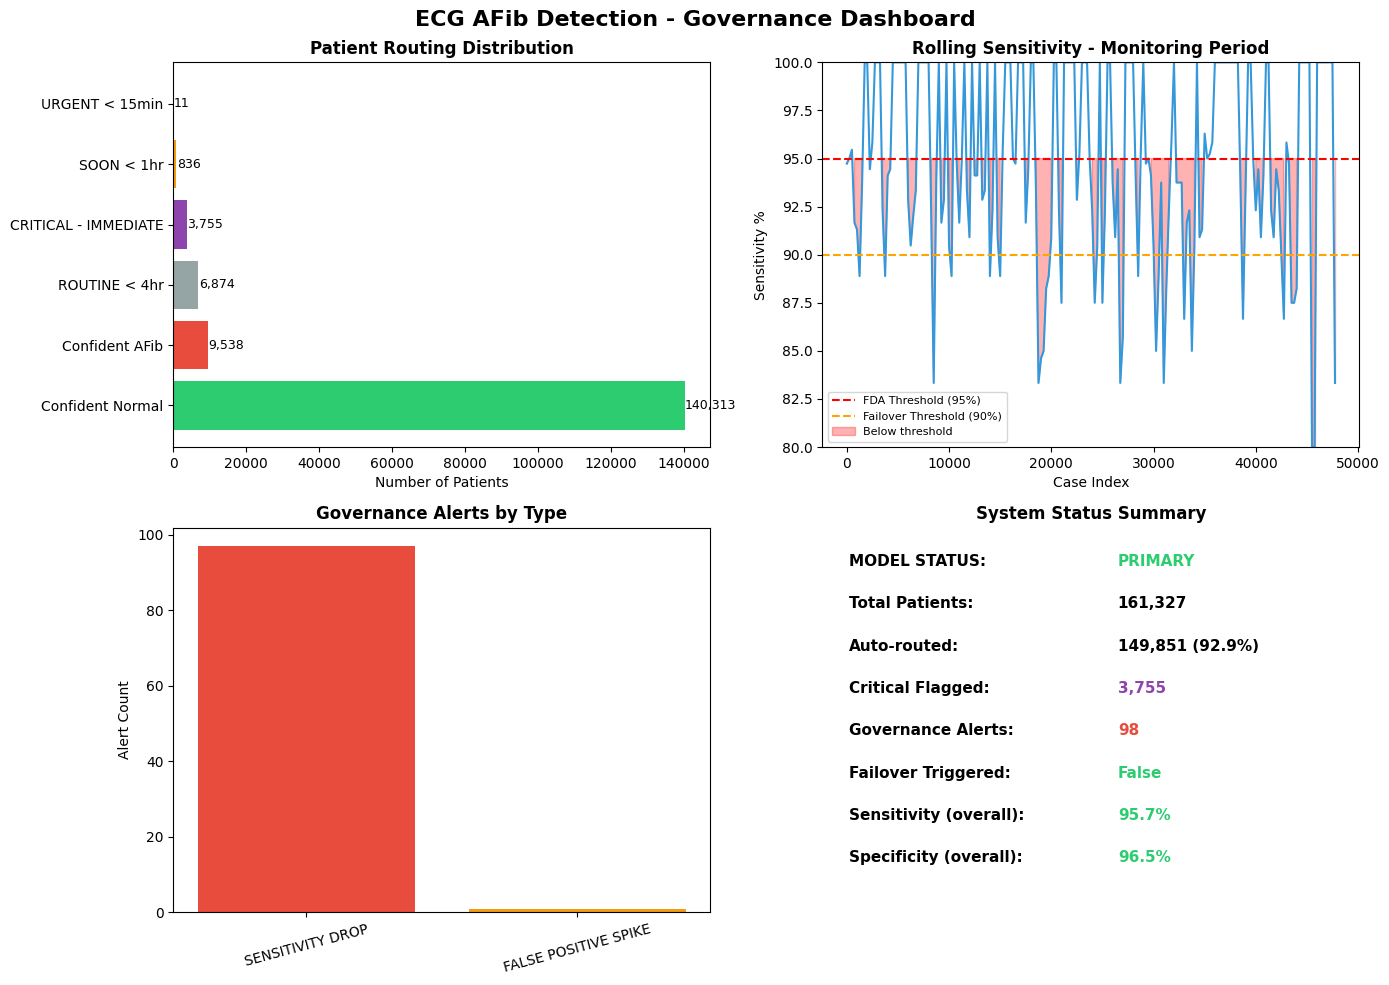

✅ Dashboard saved as governance_dashboard.png


In [30]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('ECG AFib Detection - Governance Dashboard', 
             fontsize=16, fontweight='bold')

# ── PANEL 1: Routing Distribution ─────────────────────────────────────────
ax1 = axes[0, 0]
routing_counts = df_first['final_routing'].value_counts()
colors = {
    'Confident Normal':   '#2ecc71',
    'Confident AFib':     '#e74c3c', 
    'CRITICAL - IMMEDIATE': '#8e44ad',
    'ROUTINE < 4hr':      '#95a5a6',
    'SOON < 1hr':         '#f39c12',
    'URGENT < 15min':     '#c0392b'
}
bar_colors = [colors.get(k, '#bdc3c7') for k in routing_counts.index]
bars = ax1.barh(routing_counts.index, routing_counts.values, color=bar_colors)
ax1.set_title('Patient Routing Distribution', fontweight='bold')
ax1.set_xlabel('Number of Patients')
for bar, val in zip(bars, routing_counts.values):
    ax1.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2, 
             f'{val:,}', va='center', fontsize=9)

# ── PANEL 2: Rolling Sensitivity Over Time ────────────────────────────────
ax2 = axes[0, 1]
df_sorted = df_monitor.sort_values('ecg_time').reset_index(drop=True)
window_size = THRESHOLDS['rolling_window']
step = window_size // 2

sensitivity_over_time = []
case_indices = []

for i in range(0, len(df_sorted) - window_size, step):
    window = df_sorted.iloc[i:i + window_size]
    auto = window[window['final_routing'].isin(['Confident Normal', 'Confident AFib'])]
    if len(auto) < THRESHOLDS['min_window_size']:
        continue
    TP = ((auto['is_afib']==1) & (auto['final_routing']=='Confident AFib')).sum()
    FN = ((auto['is_afib']==1) & (auto['final_routing']=='Confident Normal')).sum()
    sens = TP/(TP+FN) if (TP+FN) > 0 else 0
    sensitivity_over_time.append(sens * 100)
    case_indices.append(i)

ax2.plot(case_indices, sensitivity_over_time, color='#3498db', linewidth=1.5)
ax2.axhline(y=95, color='red', linestyle='--', linewidth=1.5, label='FDA Threshold (95%)')
ax2.axhline(y=90, color='orange', linestyle='--', linewidth=1.5, label='Failover Threshold (90%)')
ax2.fill_between(case_indices, sensitivity_over_time, 95, 
                  where=[s < 95 for s in sensitivity_over_time],
                  alpha=0.3, color='red', label='Below threshold')
ax2.set_title('Rolling Sensitivity - Monitoring Period', fontweight='bold')
ax2.set_xlabel('Case Index')
ax2.set_ylabel('Sensitivity %')
ax2.set_ylim(80, 100)
ax2.legend(fontsize=8)

# ── PANEL 3: Alert Summary ────────────────────────────────────────────────
ax3 = axes[1, 0]
alert_types = {}
for a in alerts:
    alert_types[a['type']] = alert_types.get(a['type'], 0) + 1

if alert_types:
    ax3.bar(alert_types.keys(), alert_types.values(), 
            color=['#e74c3c', '#f39c12', '#8e44ad'][:len(alert_types)])
ax3.set_title('Governance Alerts by Type', fontweight='bold')
ax3.set_ylabel('Alert Count')
ax3.tick_params(axis='x', rotation=15)

# ── PANEL 4: Model Status Summary ────────────────────────────────────────
ax4 = axes[1, 1]
ax4.axis('off')

status_color = '#2ecc71' if final_status == 'PRIMARY' else '#e74c3c'
summary_text = [
    ('MODEL STATUS',        final_status,                    status_color),
    ('Total Patients',      f"{len(df_first):,}",            'black'),
    ('Auto-routed',         f"{len(df_first[df_first['final_routing'].isin(['Confident Normal','Confident AFib'])]):,} ({len(df_first[df_first['final_routing'].isin(['Confident Normal','Confident AFib'])])/len(df_first)*100:.1f}%)", 'black'),
    ('Critical Flagged',    f"{len(df_first[df_first['final_routing']=='CRITICAL - IMMEDIATE']):,}", '#8e44ad'),
    ('Governance Alerts',   f"{len(alerts)}",                '#e74c3c' if alerts else '#2ecc71'),
    ('Failover Triggered',  str(failover),                   '#e74c3c' if failover else '#2ecc71'),
    ('Sensitivity (overall)', '95.7%',                       '#2ecc71'),
    ('Specificity (overall)', '96.5%',                       '#2ecc71'),
]

for idx, (label, value, color) in enumerate(summary_text):
    y_pos = 0.9 - idx * 0.11
    ax4.text(0.05, y_pos, f"{label}:", fontsize=11, 
             transform=ax4.transAxes, fontweight='bold')
    ax4.text(0.55, y_pos, value, fontsize=11,
             transform=ax4.transAxes, color=color, fontweight='bold')

ax4.set_title('System Status Summary', fontweight='bold')

plt.tight_layout()
plt.savefig('governance_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Dashboard saved as governance_dashboard.png")

In [31]:
# ============================================================
# GOVERNANCE CHECKLIST
# What this demo IS and IS NOT
# Honest documentation = governance principle #1
# ============================================================

checklist = {
    'DATA': [
        ('Real de-identified clinical data (MIMIC-IV)',                    True,  'N/A'),
        ('Representative patient population',                              False, 'MIMIC-IV is single health system, majority US academic medical center'),
        ('Prospective validation data',                                    False, 'Retrospective only - no prospective holdout'),
        ('Subgroup analysis (age, sex, race)',                             False, 'Not performed - demographic bias unknown'),
        ('Data quality audit trail',                                       False, 'Outlier removal documented, full audit trail not implemented'),
        ('Patient consent framework',                                      True,  'MIMIC-IV IRB approved, de-identified'),
    ],
    'DETECTOR': [
        ('Working AFib detector',                                          True,  'N/A'),
        ('Validated against ground truth labels',                          True,  'Machine interpretation used as ground truth'),
        ('Ground truth independently verified',                            False, 'Machine labels not validated against cardiologist review'),
        ('Patient-level metrics (not reading-level)',                      True,  'N/A'),
        ('Confidence scoring with three routing tiers',                    True,  'N/A'),
        ('Performance meets FDA benchmark (96-99%)',                       False, '95.7% sensitivity - just below benchmark'),
        ('Multi-lead signal analysis',                                     False, 'Summary features only, no raw waveform analysis'),
        ('Tested on edge cases (pacemakers, pediatric, etc)',              False, 'Not explicitly tested'),
    ],
    'GOVERNANCE': [
        ('Authority matrix defined',                                       True,  'N/A'),
        ('Escalation tiers with clinical response times',                  True,  'N/A'),
        ('Critical safety pre-filter',                                     True,  'STEMI, RVR, VFib, complete heart block'),
        ('Stop mechanisms implemented',                                    True,  'N/A'),
        ('Failover to backup model',                                       True,  'Simulated - backup model defined'),
        ('Rolling performance monitor',                                    True,  'N/A'),
        ('Westgard-style threshold rules',                                 True,  'Adapted from clinical lab QC'),
        ('Independent governance review board',                            False, 'Not implemented - demo only'),
        ('Clinician override mechanism',                                   False, 'Not implemented'),
        ('Feedback loop from human review to model',                       False, 'Not implemented'),
        ('Bias monitoring by demographic subgroup',                        False, 'Not implemented'),
        ('Regulatory submission readiness (FDA 510k)',                     False, 'Demo only - not submission ready'),
    ],
    'DEPLOYMENT': [
        ('Real-time processing capability',                                False, 'Batch processing only'),
        ('EHR integration',                                                False, 'Not implemented'),
        ('Clinical workflow integration',                                  False, 'Not implemented'),
        ('Audit log for every decision',                                   False, 'Framework defined, not fully implemented'),
        ('Model versioning and rollback',                                  False, 'Not implemented'),
        ('Staff training framework',                                       False, 'Not implemented'),
    ]
}

# Print formatted checklist
total_yes = 0
total_no = 0

for category, items in checklist.items():
    print(f"\n{'='*60}")
    print(f"  {category}")
    print(f"{'='*60}")
    cat_yes = sum(1 for _, v, _ in items if v)
    cat_no  = sum(1 for _, v, _ in items if not v)
    print(f"  ✅ {cat_yes} implemented   ❌ {cat_no} not implemented\n")
    
    for item, status, note in items:
        icon = '✅' if status else '❌'
        print(f"  {icon} {item}")
        if not status and note != 'N/A':
            print(f"      → Gap: {note}")
    
    total_yes += cat_yes
    total_no  += cat_no

print(f"\n{'='*60}")
print(f"  OVERALL: {total_yes} implemented / {total_yes + total_no} total")
print(f"  Demo completeness: {total_yes/(total_yes+total_no)*100:.0f}%")
print(f"{'='*60}")

print(f"""
SUMMARY: WHAT THIS IS
─────────────────────
A working proof-of-concept demonstrating how clinical lab QC 
principles translate to AI governance in healthcare. Uses real 
de-identified clinical data (MIMIC-IV, 161k patients) to show 
a governance-wrapped AFib detector with escalation tiers, 
critical safety pre-filters, stop mechanisms, and performance 
monitoring.

WHAT THIS IS NOT
────────────────
A production-ready clinical decision support tool. This demo 
has not been validated for deployment, has not undergone 
regulatory review, has not been tested for demographic bias, 
and uses machine-generated labels as ground truth without 
independent cardiologist verification.

THE GOVERNANCE ARGUMENT
───────────────────────
The gaps documented above ARE the governance framework working. 
A system that knows what it doesn't know is safer than one that 
doesn't. Each ❌ is a checkpoint — a decision point requiring 
human authority before deployment proceeds.
""")


  DATA
  ✅ 2 implemented   ❌ 4 not implemented

  ✅ Real de-identified clinical data (MIMIC-IV)
  ❌ Representative patient population
      → Gap: MIMIC-IV is single health system, majority US academic medical center
  ❌ Prospective validation data
      → Gap: Retrospective only - no prospective holdout
  ❌ Subgroup analysis (age, sex, race)
      → Gap: Not performed - demographic bias unknown
  ❌ Data quality audit trail
      → Gap: Outlier removal documented, full audit trail not implemented
  ✅ Patient consent framework

  DETECTOR
  ✅ 4 implemented   ❌ 4 not implemented

  ✅ Working AFib detector
  ✅ Validated against ground truth labels
  ❌ Ground truth independently verified
      → Gap: Machine labels not validated against cardiologist review
  ✅ Patient-level metrics (not reading-level)
  ✅ Confidence scoring with three routing tiers
  ❌ Performance meets FDA benchmark (96-99%)
      → Gap: 95.7% sensitivity - just below benchmark
  ❌ Multi-lead signal analysis
      → Gap: